## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [6]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df =  pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [8]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [9]:
# TODO: drop the Customer ID column  
df.drop(columns='Customer ID', inplace=True)

### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [10]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Co

In [11]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [12]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [13]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [14]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender']=='Male']
female_df = df[df['Gender']=='Female']

In [15]:
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


## **EDA**

### **Item Purchased**

In [21]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
top_items_all = df['Item Purchased'].value_counts().reset_index()
print("--- Top 5 mặt hàng của TẤT CẢ khách hàng ---")
print(top_items_all.head())

top_items_male = male_df['Item Purchased'].value_counts().reset_index()
print("--- Top 5 mặt hàng của khách hàng nam ---")
print(top_items_male.head())

top_items_female = female_df['Item Purchased'].value_counts().reset_index()
print("--- Top 5 mặt hàng của khách hàng nữ")
print(top_items_female.head())

--- Top 5 mặt hàng của TẤT CẢ khách hàng ---
  Item Purchased  count
0         Blouse    171
1          Pants    171
2        Jewelry    171
3          Shirt    169
4          Dress    166
--- Top 5 mặt hàng của khách hàng nam ---
  Item Purchased  count
0          Pants    123
1        Jewelry    119
2          Dress    114
3           Coat    114
4        Sweater    114
--- Top 5 mặt hàng của khách hàng nữ
  Item Purchased  count
0         Blouse     66
1          Shirt     59
2        Sandals     59
3        Handbag     58
4          Socks     58


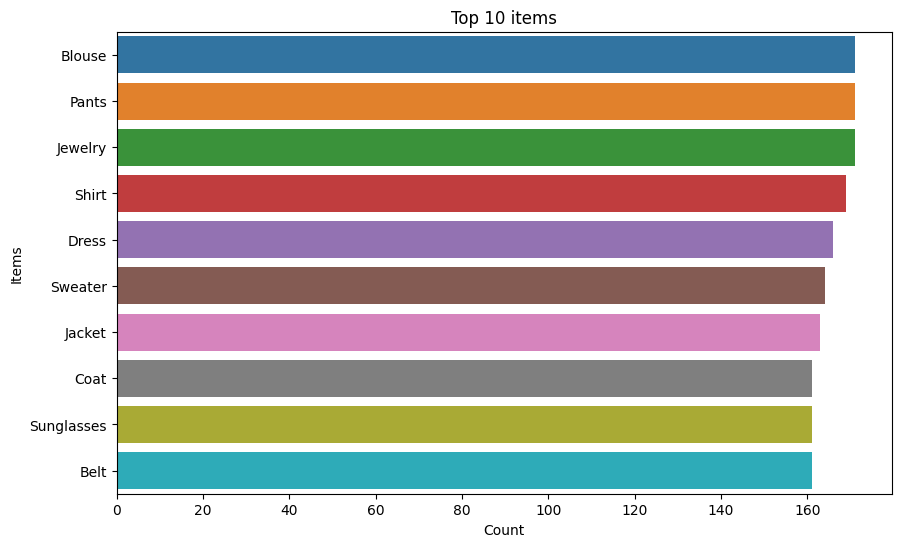

In [38]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
#     legend=?
# )
# plt.title?
# plt.xlabel?
# plt.ylabel?
# plt.show()


top_items_all.columns = ['Item', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(
    data= top_items_all.head(10),
    x= 'Count',
    y= 'Item',
    hue='Item',
)

plt.title("Top 10 items");
plt.xlabel("Count");
plt.ylabel("Items");

plt.show()


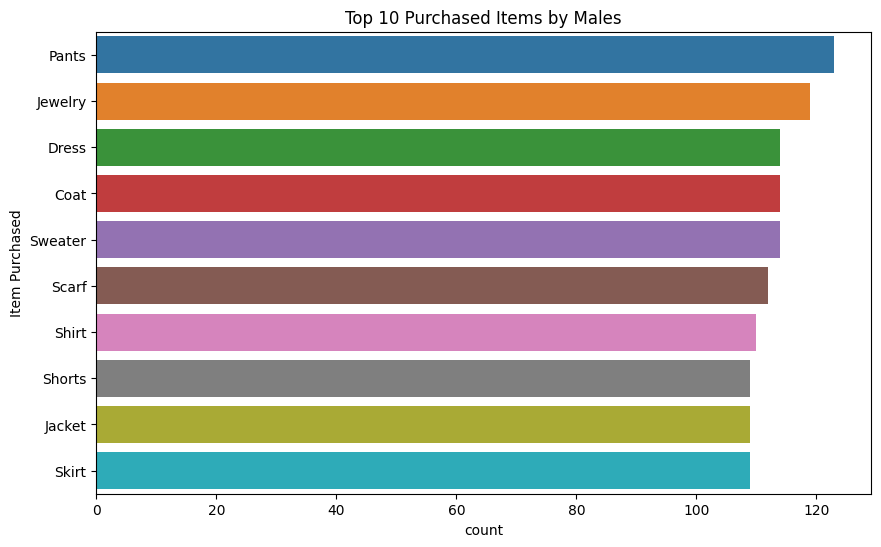

In [39]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
# )
# plt.title("Top 10 Purchased Items by Males")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()
top_items_male.columns = ['Item', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(
    data= top_items_male.head(10),
    x='Count',
    y= 'Item',
    hue='Item',
)

plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

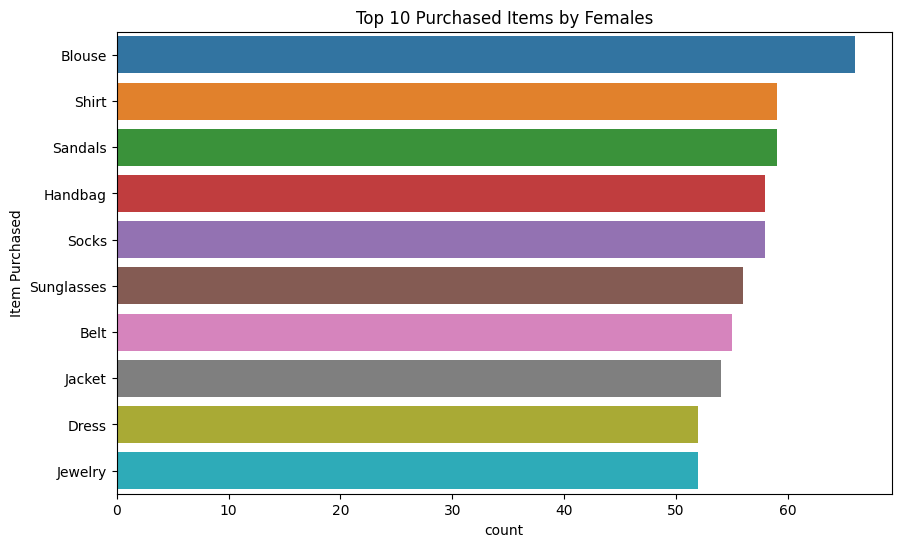

In [37]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_item_f.head(10),
#     y='Item Purchased',
#     x='count',
#     hue='Item Purchased',
#     dodge=False,
#     legend=False
# )
# plt.title("Top 10 Purchased Items by Females")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()
top_items_female.columns = ['Item', 'Count']
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_items_female.head(10),
    y='Item',
    x='Count',
    hue='Item',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [ ]:
# TODO: count Size with value_counts() for all customers
size_count = df['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [43]:
# TODO: count Size with value_counts() for male_df and female_df
size_count_male = male_df['Size'].value_counts()
size_count_female = female_df['Size'].value_counts()

print(size_count_male)
print(size_count_female)

Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [44]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg = df['Category'].value_counts().reset_index()
print(ctg)

      Category  count
0     Clothing   1737
1  Accessories   1240
2     Footwear    599
3    Outerwear    324


In [47]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg_male = male_df['Category'].value_counts().reset_index()
ctg_female = female_df['Category'].value_counts().reset_index()

print("--- Count Category male ---")
print(ctg_male)
print("--- Count Category female ---")
print(ctg_female)

--- Count Category male ---
      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
--- Count Category female ---
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


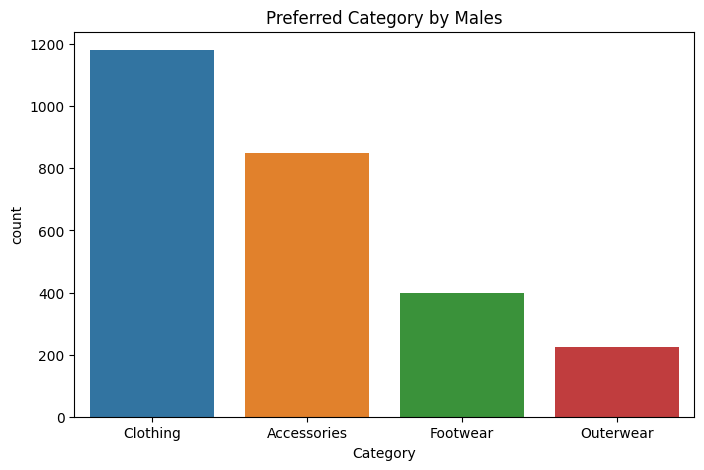

In [48]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     ?
# )
# plt.title("Preferred Category by Males")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()
ctg_male.columns = ['Category', 'count']
plt.figure(figsize=(8, 5))
sns.barplot(
    data= ctg_male,
    x='Category',
    y='count',
    hue='Category'
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

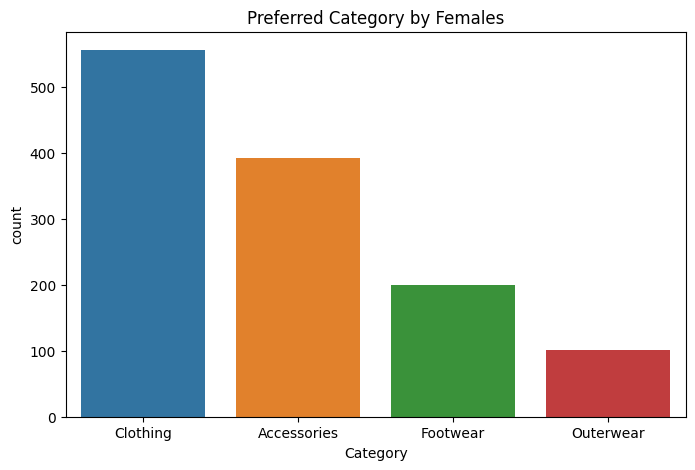

In [50]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()
ctg_female.columns = ['Category', 'count']
plt.figure(figsize=(8, 5))
sns.barplot(
    data= ctg_female,
    x='Category',
    y='count',
    hue='Category'
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

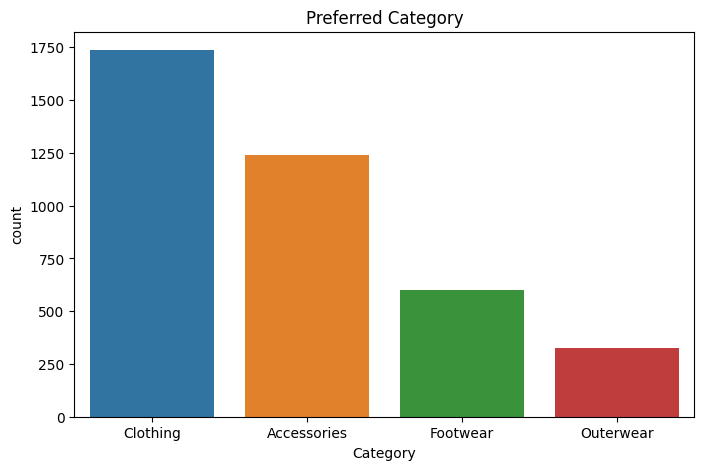

In [51]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     data=ctg,
#     x='Category',
#     y='count',
#     hue='Category',
#     dodge=False,
#     legend=False
# )
# plt.title("Preferred Category by both Genders")
# plt.show()
ctg.columns = ['Category', 'count']
plt.figure(figsize=(8, 5))
sns.barplot(
    data= ctg,
    x='Category',
    y='count',
    hue='Category'
)
plt.title("Preferred Category")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

In [53]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
# waffle_data_m = dict(male_df['Category'].value_counts())
# waffle_data_f = dict(female_df['Category'].value_counts())
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())
# print(waffle_data_f)

# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_f = dict(female_df['Category'].value_counts())

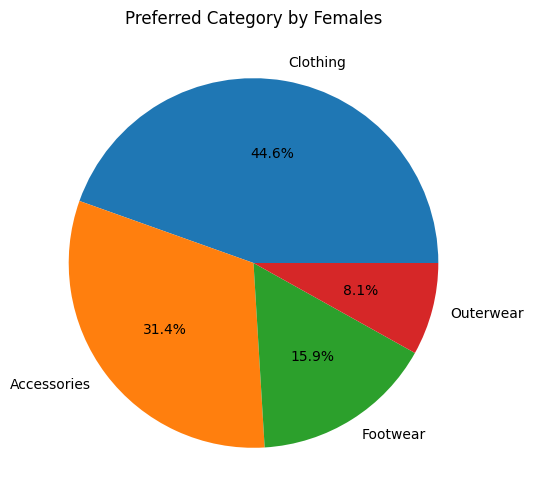

In [55]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.show()
plt.figure(figsize=(6, 6))
plt.pie(
   x=waffle_data_f.values(),
   labels=waffle_data_f.keys(),
   autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

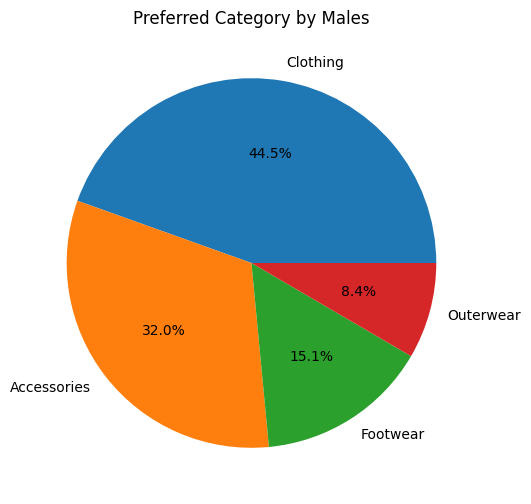

In [56]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#     waffle_data_m.values(),
#     labels=waffle_data_m.keys(),
#     autopct='%1.1f%%'
# )
# plt.title("Preferred Category by Males")
# plt.show() 
plt.figure(figsize=(6, 6))
plt.pie(
   x=waffle_data_m.values(),
   labels=waffle_data_m.keys(),
   autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show()

### **Review ratings**

In [58]:
female_df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2652,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,46,Credit Card,Monthly
2653,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Credit Card,Express,No,No,24,Venmo,Every 3 Months
2654,23,Female,Coat,Outerwear,70,Idaho,S,Pink,Fall,4.1,No,Debit Card,Next Day Air,No,No,4,PayPal,Annually
2655,26,Female,Sunglasses,Accessories,83,Wyoming,M,Gray,Summer,3.4,No,Credit Card,Standard,No,No,2,Credit Card,Fortnightly
2656,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Bank Transfer,Express,No,No,29,Bank Transfer,Fortnightly


In [ ]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f = ?
# avg_cr_f = ?
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()

In [60]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()

In [61]:
# avg_cr_m,avg_cr_f
print(f"Điểm trung bình đánh giá Clothing của nam: {avg_cr_m}")
print(f"Điểm trung bình đánh giá Clothing của nữ: {avg_cr_f}")

Điểm trung bình đánh giá Clothing của nam: 3.7319220999153258
Điểm trung bình đánh giá Clothing của nữ: 3.7044964028776977


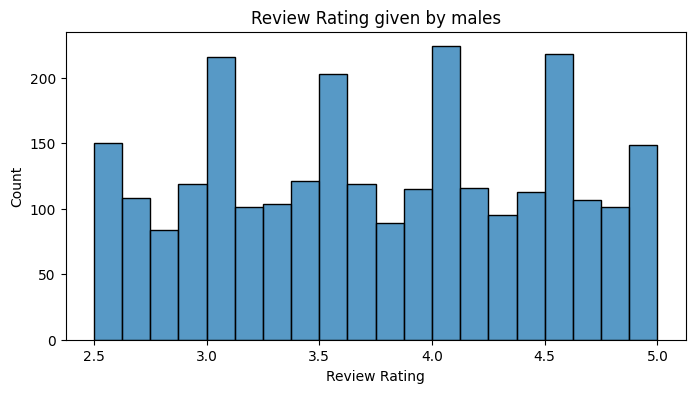

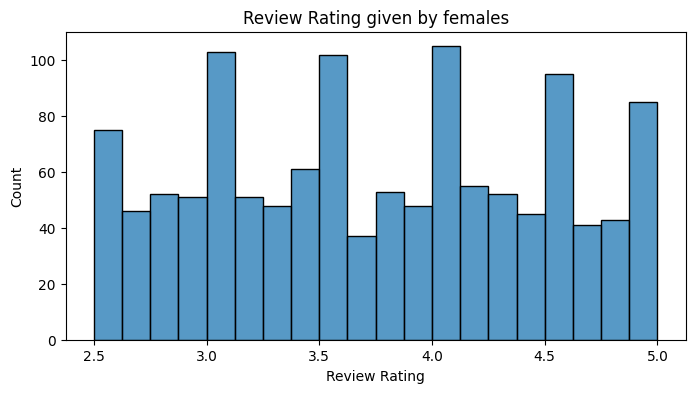

In [63]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
# ?
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [66]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
review_count_male = cr_m['Review Rating'].value_counts()
print(review_count_male)

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.2    52
3.9    52
4.0    52
3.0    49
3.3    49
4.1    48
4.9    48
3.5    48
3.6    46
4.8    46
4.7    46
3.1    46
4.6    46
4.3    45
2.6    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64


### **Purchase Amount (USD)**

In [68]:
# TODO: sum Purchase Amount (USD) for males
# m_tpa = ?
m_tpa = male_df['Purchase Amount (USD)'].sum()
print(m_tpa)
# # TODO: sum Purchase Amount (USD) for females
# f_tpa =?
f_tpa = female_df['Purchase Amount (USD)'].sum()
print(f_tpa)

157890
75191


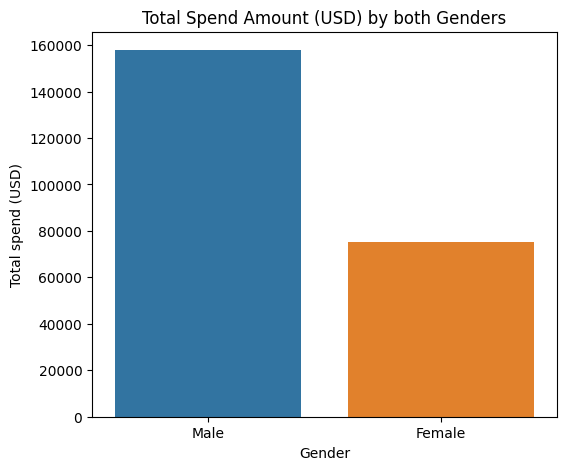

In [70]:
# TODO: plot total spend by gender with sns.barplot()
# plt.figure(figsize=(6, 5))
# sns.barplot(
#     ?
# )
# plt.title("Total Spend Amount (USD) by both Genders")
# plt.ylabel('Total spend (USD)')
# plt.show()
plot_data = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total Spend': [m_tpa, f_tpa]
})
plt.figure(figsize=(6, 5))
sns.barplot(
    data= plot_data,
    x= 'Gender',
    y= 'Total Spend',
    hue= 'Gender'
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [73]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_f = cr_f
# ca_f = female_df[female_df['Category']=='Accessories']
# cf_f = ?
# co_f = ?
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [74]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_m = cr_m
# ca_m = ?
# cf_m = ?
# co_m = ?
cc_m = cr_m
ca_m = male_df[male_df['Category']== 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [82]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
print(pcu)

{'No': np.int64(2223), 'Yes': np.int64(1677)}


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

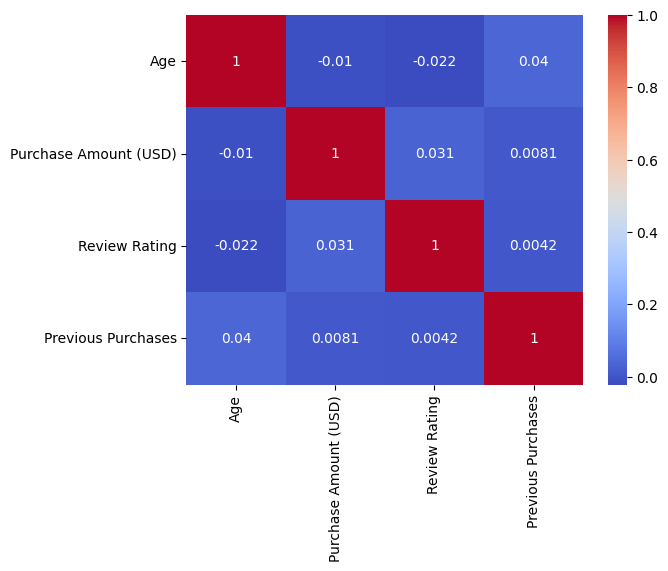

In [77]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)
sns.heatmap(
    data= corr,
    annot= True,
    cmap='coolwarm'
)
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [78]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
# df = pd.get_dummies(df, columns=[?], dtype=?)
# df.head()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [79]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# df['Amount_minmax'] = ?
# df['Age_standard'] = ?
# df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

df['Amount_minmax'] = scaler_minmax.fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = scaler_standard.fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [80]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
# df['Amount_bin'] = ?
# df['Amount_bin'].value_counts()
df['Amount_bin'] = pd.cut(
    x=df['Purchase Amount (USD)'], 
    bins=3, 
    labels=['Low', 'Medium', 'High']
)
df['Amount_bin'].value_counts()

Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Biểu đồ tổng chi tiêu theo giới tính cho thấy sự chênh lệch lớn giữa hai nhóm khách hàng. Tổng số tiền mua sắm (Purchase Amount) của nam giới (khoảng 157.890 USD) cao hơn gấp đôi so với nhóm khách hàng nữ (khoảng 75.191 USD).
- Quần áo (Clothing) là danh mục phổ biến nhất đối với cả hai giới (chiếm khoảng 44.5% ở mỗi nhóm).Đứng thứ hai cũng giống nhau, đó là Phụ kiện (Accessories) (chiếm khoảng 31.4% - 31.9%).Tiếp theo lần lượt là Giày dép (Footwear) và Đồ mặc ngoài (Outerwear).
Về mặt hàng cụ thể, Đối với Nam giới: Các mặt hàng được mua nhiều nhất thường tập trung vào Quần dài (Pants), Trang sức (Jewelry), Áo khoác (Coat) và Áo len (Sweater).Đối với Nữ giới: Xu hướng mua sắm lại tập trung nhiều nhất vào Áo kiểu (Blouse), Áo sơ mi (Shirt), Váy (Dress) và Túi xách (Handbag).
- Mức độ hài lòng của khách hàng đối với các sản phẩm là tương đương nhau ở cả hai giới tính. Với điểm đánh giá trung bình dao động quanh mức 3.7/5.
- Tần suất sử dụng mã khuyến mãi là 43% (1.677 giao dịch có sử dụng mã trên tổng số 3.900 giao dịch). Ngược lại, có đến 57% (2.223 giao dịch) hoàn tất mua sắm mà không dùng bất kỳ mã giảm giá nào.

Caveat: correlation is not causation.